# Classification

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
plt.rcParams['figure.figsize'] = (12, 8)
from sklearn.metrics import accuracy_score,classification_report
from sklearn.datasets import make_moons,make_blobs,make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.base import clone
from sklearn.multiclass import OneVsRestClassifier
from dataset import CovtypeDataset as Dataset
from eda.eda import EDA
from classification.pipeline import get_pipeline


# Logistic regression
from classification.logistic_regression.softmax import SoftmaxClassifier
from classification.logistic_regression.sigmoid import SigmoidClassifier
from classification.logistic_regression.irls import IRLSClassifier

# Discriminant Analysis
from classification.lda.lda import LDA
from classification.lda.qda import QDA
from classification.lda.fisher_ratio import fisher_ratio

# Perceptron and Regularization
from classification.perceptron_logreg.perceptron import Perceptron
from classification.perceptron_logreg.class_weighted import WeightedSoftmaxClassifier
from classification.perceptron_logreg.lambda_selection import select_best_lambda

# Advanced
from classification.advanced.probit import ProbitClassifier
from classification.advanced.laplace import LaplaceApprox
from classification.advanced.kernel_logistic import KernelLogisticRegression

from evaluation.evaluator import Evaluator
from evaluation.visualizer import Visualizer

## Dataset

In [3]:
d = Dataset()

### EDA

In [ ]:
eda = EDA(d)

#### Missing values

In [ ]:
print(eda.missing_values())

#### Target distribution

In [ ]:
print(eda.target_distribution())

In [ ]:
eda.plot_target_distribution()
plt.show()

#### Numeric features

In [ ]:
eda.plot_numeric_features()
plt.show()

#### Categorical features

In [ ]:
eda.plot_categorical_features()
plt.show()

#### Numeric features vs Target

In [ ]:
eda.plot_numeric_vs_target()
plt.show()

#### Preprocessing

In [4]:
d.split()

## Models

### Logistic regression

#### Sigmoid

Acc = 0.7983


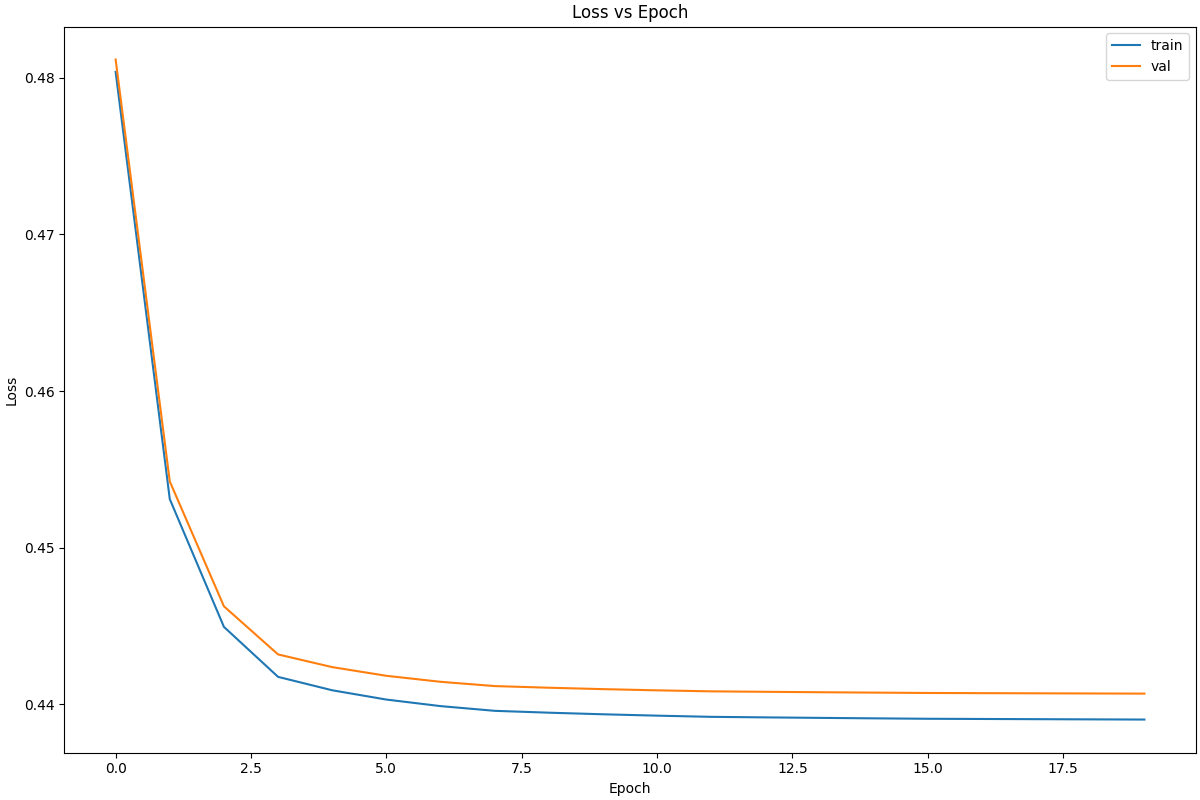

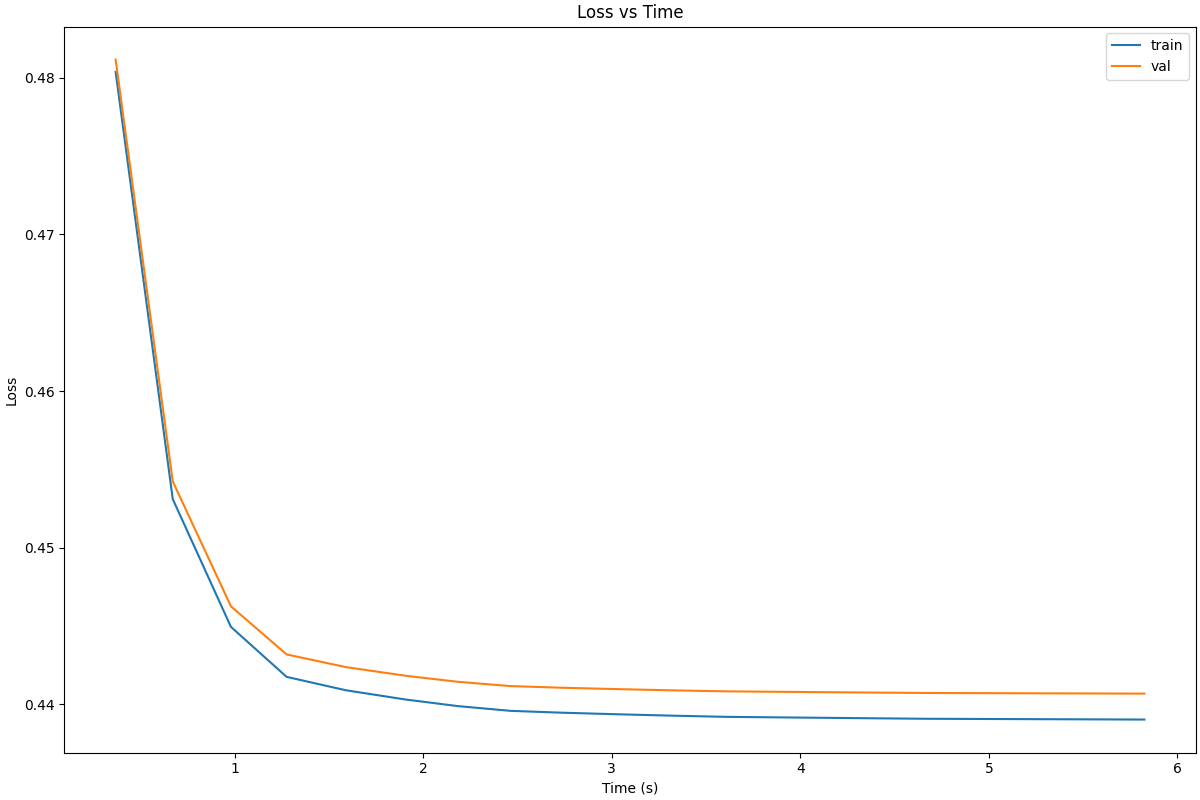

In [7]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# dataset
X, y = make_classification(
    n_samples=500_000,
    n_features=10,
    n_informative=6,
    n_classes=2,
    random_state=42
)

# split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# model
model = SigmoidClassifier(
    max_iter=20,
    step_size=4,
    batch_size=1024
)

# fit
model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

# accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Acc = {acc:.4f}")

# ===== PLOT =====
epochs = range(len(model.train_loss_history_))

# 1. loss vs epoch
plt.figure(layout="constrained")
plt.plot(epochs, model.train_loss_history_, label="train")
plt.plot(epochs, model.val_loss_history_, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# 2. loss vs time
plt.figure(layout="constrained")
plt.plot(model.time_history_, model.train_loss_history_, label="train")
plt.plot(model.time_history_, model.val_loss_history_, label="val")
plt.xlabel("Time (s)")
plt.ylabel("Loss")
plt.title("Loss vs Time")
plt.legend()
plt.show()

#### Newton-Raphson IRLS

In [ ]:
# model
model = IRLSClassifier()

# fit
model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

# accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Acc = {acc:.4f}")

# ===== PLOT =====
epochs = range(len(model.train_loss_history_))

# 1. loss vs epoch
plt.figure(layout="constrained")
plt.plot(epochs, model.train_loss_history_, label="train")
plt.plot(epochs, model.val_loss_history_, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# 2. loss vs time
plt.figure(layout="constrained")
plt.plot(model.time_history_, model.train_loss_history_, label="train")
plt.plot(model.time_history_, model.val_loss_history_, label="val")
plt.xlabel("Time (s)")
plt.ylabel("Loss")
plt.title("Loss vs Time")
plt.legend()
plt.show()

#### Softmax

In [ ]:
softmax = SoftmaxClassifier()
softmax.fit(d.X_train, d.y_train)
y_pred = softmax.predict(d.X_test)
y_true = d.y_test
acc = accuracy_score(y_true, y_pred)
print(f"Acc = {acc:.4f}")

### LDA & QDA

#### LDA

In [ ]:
model = get_pipeline(LDA(n_components=2))
model.fit(d.X_train, d.y_train)

In [ ]:
y_pred = model.predict(d.X_test)
y_true = d.y_test
acc = accuracy_score(y_true, y_pred)
print(f"Acc = {acc:.4f}")

#### Decision Boundary 2D

In [ ]:
model.named_steps["predictor"].plot2D(d.X_train, d.y_train)

#### QDA

In [ ]:
model = get_pipeline(QDA())
model.fit(d.X_train, d.y_train)

In [ ]:
y_pred = model.predict(d.X_test)
y_true = d.y_test
acc = accuracy_score(y_true, y_pred)
print(f"Acc = {acc:.4f}")

#### Fisher ratio

In [ ]:
J_scores = fisher_ratio(d.X_train, d.y_train)
df_ranking = pd.DataFrame({
    'Feature': d.feature_names,
    'Fisher_Ratio': J_scores
}).sort_values(by='Fisher_Ratio', ascending=False).reset_index(drop=True)
print(df_ranking)

### Perceptron & Regularization

#### Perceptron

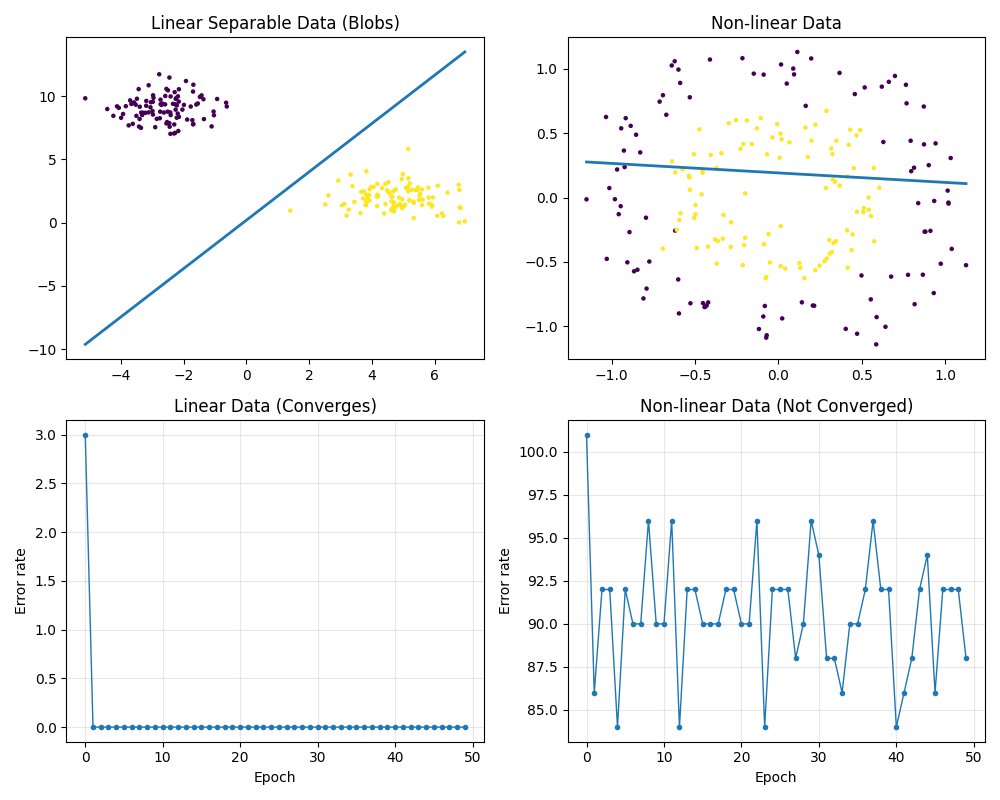

Linear: Converged
Non-linear: Not converged


In [10]:
# ===== 1. LINEAR DATA =====
result = make_blobs(n_samples=200, centers=2, random_state=42)
X_linear, y_linear = result[:2]
y_linear = np.where(y_linear == 0, -1, 1)

model1 = Perceptron(lr=0.01, epochs=50)
model1.fit(X_linear, y_linear)

# ===== 2. NON-LINEAR DATA =====
X_non, y_non = make_circles(n_samples=200, noise=0.1, factor=0.5)
y_non = np.where(y_non == 0, -1, 1)

model2 = Perceptron(lr=0.01, epochs=50)
model2.fit(X_non, y_non)

# ===== PLOT =====
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear,s=5)
# draw decision boundary
x_vals = np.linspace(X_linear[:, 0].min(), X_linear[:, 0].max(), 100)
y_vals = -(model1.w[0] * x_vals + model1.b) / model1.w[1]
plt.plot(x_vals, y_vals, linewidth=2)
plt.title("Linear Separable Data (Blobs)")

plt.subplot(2, 2, 2)
plt.scatter(X_non[:, 0], X_non[:, 1], c=y_non,s=5)
x_vals = np.linspace(X_non[:, 0].min(), X_non[:, 0].max(), 100)
y_vals = -(model2.w[0] * x_vals + model2.b) / model1.w[1]
plt.plot(x_vals, y_vals, linewidth=2)
plt.title("Non-linear Data")

plt.subplot(2, 2, 3)
plt.plot(model1.errors_, marker='o', markersize=3, linewidth=1)
plt.title("Linear Data (Converges)")
plt.xlabel("Epoch")
plt.ylabel("Error rate")
plt.grid(alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(model2.errors_, marker='o', markersize=3, linewidth=1)
plt.title("Non-linear Data (Not Converged)")
plt.xlabel("Epoch")
plt.ylabel("Error rate")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===== PRINT =====
print("Linear:", "Converged" if model1.errors_[-1] == 0 else "Not converged")
print("Non-linear:", "Converged" if model2.errors_[-1] == 0 else "Not converged")

#### Regularization

In [8]:

# ===== L1 Logistic Regression =====
model_l1 = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.01, 
    max_iter=2000
)
model_l1.fit(X_train, y_train)

# ===== L2 Logistic Regression =====
model_l2 = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000
)
model_l2.fit(X_train, y_train)

# ===== Accuracy =====
acc_l1 = accuracy_score(y_test, model_l1.predict(X_test))
acc_l2 = accuracy_score(y_test, model_l2.predict(X_test))

# ===== Sparsity =====
w_l1 = model_l1.coef_
w_l2 = model_l2.coef_

sparsity_l1 = np.mean(np.abs(w_l1) < 1e-6)
sparsity_l2 = np.mean(np.abs(w_l2) < 1e-6)

print("=== RESULTS ===")
print("L1 Accuracy:", acc_l1)
print("L2 Accuracy:", acc_l2)
print("L1 Sparsity:", sparsity_l1)
print("L2 Sparsity:", sparsity_l2)

d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of pe

=== RESULTS ===
L1 Accuracy: 0.7988266666666667
L2 Accuracy: 0.7989466666666667
L1 Sparsity: 0.3
L2 Sparsity: 0.0


#### Stratified k-fold CV

In [9]:
X = d.X
y = d.y
print("Dataset shape:", X.shape)
print("Class distribution:", np.bincount(y))

# ===== Lambda=====
lambdas = [0.001, 0.01, 0.1, 1, 10]

# ===== Function choose best lambda =====
best_lambda, best_score = select_best_lambda(X, y, lambdas)

print("\n=== RESULT ===")
print("Best lambda:", best_lambda)
print("Best log loss:", best_score)

Dataset shape: (581012, 54)
Class distribution: [     0 211840 283301  35754   2747   9493  17367  20510]


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will

Lambda = 0.001, Log Loss = 0.6290


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will

Lambda = 0.01, Log Loss = 0.6290


...

Lambda = 0.1, Log Loss = 0.6290


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will

Lambda = 1, Log Loss = 0.6290


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will

Lambda = 10, Log Loss = 0.6292

=== RESULT ===
Best lambda: 0.01
Best log loss: 0.6289983569404619


#### Class-weighted loss


In [59]:
print("========== WITHOUT CLASS WEIGHT ==========")
model_no_weight = WeightedSoftmaxClassier(lr=0.05, epochs=500)

model_no_weight._compute_class_weights = lambda y, K: np.ones(K)

model_no_weight.fit(X_train, y_train)
y_pred_no = model_no_weight.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_no))
print(classification_report(y_test, y_pred_no, digits=4))

# ===== Model contain weight =====
print("\n========== WITH CLASS WEIGHT ==========")
model_weight = WeightedSoftmaxClassier(lr=0.05, epochs=500)

model_weight.fit(X_train, y_train)
y_pred_w = model_weight.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_w))
print(classification_report(y_test, y_pred_w, digits=4))

# ===== In class weights =====
print("\n========== CLASS WEIGHTS ==========")
K = len(np.unique(y_train))
weights = model_weight._compute_class_weights(y_train, K)
for i, w in enumerate(weights):
    print(f"Class {i}: weight = {w:.4f}")

========== WITHOUT CLASS WEIGHT ==========
Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.4452


KeyboardInterrupt: 

## Advanced

### Probit

In [ ]:
from sklearn.datasets import make_blobs

centers = [[-4, 0], [0, 2]]
X, y = make_blobs(n_samples=1_000, centers=centers, cluster_std=2, random_state=40)
transformation = [[0.4, 0.3], [-0.4, 0.7]]
X = np.dot(X, transformation)

In [ ]:
def plot_decision_boundary_2features(model, X, y, f1=0, f2=1, resolution=200, title="Decision Boundary"):
    n, d = X.shape
    x_min, x_max = X[:, f1].min() - 1, X[:, f1].max() + 1
    y_min, y_max = X[:, f2].min() - 1, X[:, f2].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))

    # Grid full dimension
    X_mean = np.mean(X, axis=0)
    grid = np.tile(X_mean, (xx.size, 1))
    grid[:, f1] = xx.ravel()
    grid[:, f2] = yy.ravel()

    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, f1], X[:, f2], c=y, s=20, edgecolor="k", cmap="coolwarm")
    plt.xlabel(f"Feature {f1}")
    plt.ylabel(f"Feature {f2}")
    plt.title(title)
    plt.show()

def plot_probability_2features(model, X, y, f1=0, f2=1, class_idx=1, resolution=200, title="Probability"):
    n, d = X.shape
    x_min, x_max = X[:, f1].min() - 1, X[:, f1].max() + 1
    y_min, y_max = X[:, f2].min() - 1, X[:, f2].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))

    X_mean = np.mean(X, axis=0)
    grid = np.tile(X_mean, (xx.size, 1))
    grid[:, f1] = xx.ravel()
    grid[:, f2] = yy.ravel()

    Z = model.predict_proba(grid)[:, class_idx].reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=50, cmap="viridis")
    plt.scatter(X[:, f1], X[:, f2], c=y, s=20, edgecolor="k", cmap="viridis")
    plt.colorbar(label=f"p(class={class_idx})")
    plt.xlabel(f"Feature {f1}")
    plt.ylabel(f"Feature {f2}")
    plt.title(title)
    plt.show()


sigmoid = SigmoidClassifier()
sigmoid.fit(X, y)

probit = ProbitClassifier()
probit.fit(X, y)

#### Decision boundary

In [ ]:
plot_decision_boundary_2features(sigmoid, X, y, f1=0, f2=1, title="Sigmoid Decision Boundary")
plt.show()

In [ ]:
plot_decision_boundary_2features(probit, X, y, f1=0, f2=1, title="Probit Decision Boundary")
plt.show()

#### Predict probability

In [ ]:
plot_probability_2features(sigmoid, X, y, f1=0, f2=1, class_idx=1, title="Softmax Probability Class 1")
plt.show()

In [ ]:
plot_probability_2features(probit, X, y, f1=0, f2=1, class_idx=1, title="Probit Probability Class 1")
plt.show()

#### Noise sensitivity

In [ ]:
def noisy_labels_test(model, X, y, noise_levels=[0.0, 0.1, 0.2, 0.3, 0.4], seed=42):
    np.random.seed(seed)

    accs = []
    classes = np.unique(y)

    for noise in noise_levels:
        y_noisy = y.copy()

        n_flip = int(len(y) * noise)
        flip_idx = np.random.choice(len(y), n_flip, replace=False)

        if len(classes) == 2:
            y_noisy[flip_idx] = 1 - y_noisy[flip_idx]
        else:
            y_noisy[flip_idx] = np.random.choice(classes, size=n_flip)

        m = clone(model)
        m.fit(X, y_noisy)

        y_pred = m.predict(X)

        accs.append(accuracy_score(y, y_pred))  # evaluate on clean labels

    print("noise level:", noise)
    print("changed labels:", np.mean(y_noisy == y))
    plt.plot(noise_levels, accs, marker="o")
    plt.xlabel("Fraction of label noise")
    plt.ylabel("Accuracy (clean labels)")
    plt.title(f"Robustness to label noise: {model.__class__.__name__}")
    plt.grid(True)
    plt.show()

    return accs

In [ ]:
# -------------------------------
# Độ nhạy với nhãn nhiễu
# -------------------------------
noisy_labels_test(SigmoidClassifier(), X, y)
noisy_labels_test(ProbitClassifier(), X, y)

## Laplace approximation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===== Train Sigmoid (Logistic) =====
model = SigmoidClassifier()
list(model._fit(X, y))

# ===== Laplace Approximation =====
laplace = LaplaceApprox(model)
laplace.fit(X)

# ===== Plot decision boundary + uncertainty =====
fig, ax = plt.subplots(figsize=(6,6))
laplace.decision_boundary_sigma(X, y, ax=ax)
plt.show()

#### Kernel Logistic Regression

In [ ]:
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

In [ ]:
linear_model = LogisticRegression()
linear_model.fit(X, y)

In [ ]:
kernel_model = KernelLogisticRegression(gamma=5, lr=0.01, epochs=500)
kernel_model.fit(X, y)

In [ ]:
DecisionBoundaryDisplay.from_estimator(
    linear_model,
    X,
    response_method="predict",
    alpha=0.3,
    grid_resolution=200
)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
plt.title("Linear Logistic Regression")
plt.show()

In [ ]:
DecisionBoundaryDisplay.from_estimator(
    kernel_model,
    X,
    response_method="predict",
    alpha=0.3,
    grid_resolution=200
)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
plt.title("Kernel Logistic Regression (RBF)")
plt.show()

## Evaluation

In [ ]:
models = {
    "softmax": SoftmaxClassifier(),
    "LDA": LDA()
}
